# **Bloco de Instalação**

In [ ]:
!pip install -q -U transformers accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 18.0 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import login
login("hf_YourTokenHere")

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# Nome do modelo no Hugging Face
model_id = "google/gemma-2-9b-it" # O 'it' significa Instruction Tuned (IA de chat)

# Configuração para caber no Colab gratuito (Quantização)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Carrega o Tokenizer (o tradutor de texto para números)
tokenizer = AutoTokenizer.from_pretrained(model_id)

# Carrega o Modelo (o cérebro)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Gemma 2 9B carregada com sucesso!")

config.json:   0%|          | 0.00/857 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Gemma 2 9B carregada com sucesso!


# ________________________________________________________________________________________________________________________________________________________________

# **Bloco de Uso** --- Exemplos

In [ ]:
input_text = "Analise este log: 'Failed password for user root from 192.168.1.1'. Isso é suspeito?"
inputs = tokenizer(input_text, return_tensors="pt").to("cuda")

outputs = model.generate(**inputs, max_new_tokens=100)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Analise este log: 'Failed password for user root from 192.168.1.1'. Isso é suspeito?

**Sim, este log é suspeito.**

**Aqui está o porquê:**

* **Usuário root:** O usuário root tem privilégios de administrador completos no sistema. Qualquer tentativa de acesso ao root é potencialmente perigosa.
* **Falha de senha:** A mensagem indica que a senha fornecida foi incorreta. Isso sugere que alguém está tentando adivinhar a senha do root.
* **Endereço IP:** O endereço IP 192.1


# Criando um perfil de usuário para few-shot e testando

In [ ]:
# Definindo o perfil do usuário e os logs
perfil_usuario = """
PERFIL DO USUÁRIO GENUÍNO:
- Nome: Kayo
- Localização: Rio de Janeiro, Brasil (IPs comuns: 187.12.x.x)
- Horário de Trabalho: 09:00 às 18:00.
- Comportamento: Não viaja, acessa apenas da rede local.
"""

log_para_analise = "[45000.887766] auth: Accepted password for kayo from 95.161.22.128 port 54322 ssh2 at 2026-04-06 03:22:11; COMMAND=/usr/bin/cat /etc/shadow"

# Montando o prompt estruturado
prompt = f"""
Você é um especialista em cibersegurança e Analista de IDS.
{perfil_usuario}

TAREFA:
Analise o log abaixo e determine se é uma ANOMALIA ou um acesso GENUÍNO.
Explique seu raciocínio (XAI) detalhadamente.

LOG PARA ANÁLISE:
{log_para_analise}

RESPOSTA (Siga este formato):
- VEREDITO: [ANOMALIA / GENUÍNO]
- CONFIANÇA: [0-100%] (Sendo 100% totalmente legítimo e 0% totalmente anômalo)
- JUSTIFICATIVA: [Sua explicação aqui]
"""

# Gerando a resposta
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=250)
print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Você é um especialista em cibersegurança e Analista de IDS.

PERFIL DO USUÁRIO GENUÍNO:
- Nome: Kayo
- Localização: Rio de Janeiro, Brasil (IPs comuns: 187.12.x.x)
- Horário de Trabalho: 09:00 às 18:00.
- Comportamento: Não viaja, acessa apenas da rede local.


TAREFA:
Analise o log abaixo e determine se é uma ANOMALIA ou um acesso GENUÍNO.
Explique seu raciocínio (XAI) detalhadamente.

LOG PARA ANÁLISE:
[45000.887766] auth: Accepted password for kayo from 95.161.22.128 port 54322 ssh2 at 2026-04-06 03:22:11; COMMAND=/usr/bin/cat /etc/shadow

RESPOSTA (Siga este formato):
- VEREDITO: [ANOMALIA / GENUÍNO]
- CONFIANÇA: [0-100%] (Sendo 100% totalmente legítimo e 0% totalmente anômalo)
- JUSTIFICATIVA: [Sua explicação aqui]
- DETALHES: [Detalhes adicionais sobre a análise]

**RESPOSTA:**

- VEREDITO: ANOMALIA
- CONFIANÇA: 95%
- JUSTIFICATIVA: O log apresenta diversos pontos que indicam uma tentativa de ataque:

    * **Horário Inusual:** O acesso ocorreu às 03:22, fora do horário de traba

Comentário sobre o que rolou acima:
Por que ele deu 95%?

    O Conflito de Escala: No seu prompt, você definiu que 100% = Legítimo e 0% = Anômalo. Porém, para uma IA, a palavra "Confiança" geralmente significa: "O quão seguro eu estou da resposta que acabei de dar?".

    A "Lógica Interna" da Gemma: A Gemma 2 identificou que o log era uma ANOMALIA (ela acertou em cheio na análise técnica). Ao chegar no campo "Confiança", ela pensou: "Estou muito certa de que isso é uma anomalia? Sim, 95% certa!".

    Alucinação de Instrução: Ela ignorou o texto entre parênteses (Sendo 100% totalmente legítimo...) porque, para o modelo, é contraintuitivo dizer que o veredito é "Anomalia" com uma confiança de "5%". Na cabeça matemática do modelo, "Veredito X" pede "Confiança Alta em X".

In [ ]:
perfil_kayo = """
[PERFIL DE SEGURANÇA - USUÁRIO: KAYO]
- Localização: Rio de Janeiro, Brasil.
- Horário Habitual: 09:00 às 18:00 (Segunda a Sexta).
- Comportamento: Não utiliza VPNs internacionais ou acessos remotos fora do país.
"""

historico_normal = """
[HISTÓRICO RECENTE - LOGS LIMPOS]:
- [SEG][10:15][IP_RIO] auth: session opened for user kayo
- [TER][14:30][IP_RIO] sudo: kayo : COMMAND=/usr/bin/git push
- [QUA][11:00][IP_RIO] auth: session opened for user kayo
"""

log_suspeito = "[DOMINGO][03:22][IP_RUSSIA] auth: Accepted password for kayo; COMMAND=/usr/bin/cat /etc/shadow"

# 5. MONTAGEM DO PROMPT E EXECUÇÃO DA IA
prompt = f"""
Você é um sistema de Detecção de Intrusão (IDS) baseado em IA.
Sua tarefa é analisar o LOG ATUAL comparando-o com o PERFIL e o HISTÓRICO fornecidos.

{perfil_kayo}
{historico_normal}

---
LOG ATUAL PARA ANÁLISE:
{log_suspeito}
---

Gere um relatório técnico seguindo rigorosamente este formato:
VEREDITO: [ANOMALIA ou GENUÍNO]
CONFIANÇA: [0-100%] (Sendo 100% totalmente legítimo e 0% totalmente anômalo)
ANÁLISE TEMPORAL: [Explique o impacto do horário/dia]
ANÁLISE GEOGRÁFICA: [Explique o impacto da localização/IP]
ANÁLISE DE COMANDO: [Explique o perigo do comando executado]
EXPLICAÇÃO FINAL (XAI): [Resumo para o administrador]
"""

print("--- INICIANDO ANÁLISE DE SEGURANÇA ---\n")
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
outputs = model.generate(**inputs, max_new_tokens=400, temperature=0.7)
resultado = tokenizer.decode(outputs[0], skip_special_tokens=True)

# Limpeza básica para exibir apenas a resposta da IA
print(resultado.split("Resumo para o administrador")[-1] if "Resumo para o administrador" in resultado else resultado)

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


--- INICIANDO ANÁLISE DE SEGURANÇA ---

]
---

**Relatório Técnico - Detecção de Intrusão**

**VEREDITO:** ANOMALIA
**CONFIANÇA:** 25%

**ANÁLISE TEMPORAL:** O log atual foi gerado em domingo às 03:22, fora do horário habitual de Kayo (09:00 às 18:00, segunda a sexta). O acesso fora do horário de trabalho é um sinal de alerta.

**ANÁLISE GEOGRÁFICA:** O log atual indica um acesso proveniente de um IP localizado na Rússia, enquanto o perfil de Kayo indica que ele não utiliza VPNs internacionais ou acessos remotos fora do país.

**ANÁLISE DE COMANDO:** O comando `/usr/bin/cat /etc/shadow` é extremamente perigoso. Ele lê o arquivo `/etc/shadow`, que contém as senhas hash de todos os usuários do sistema. O acesso a este arquivo por um usuário não autorizado indica uma tentativa de roubo de senhas.

**EXPLICAÇÃO FINAL (XAI):**  O sistema detectou um acesso suspeito ao sistema de Kayo. O acesso ocorreu fora do horário habitual, proveniente de uma localização geográfica diferente do perfil de

# Agora, ussando a LLM para processar os dados de um log e deixar eles bonitinhos.


In [ ]:
# 1. LOG BRUTO
log_bruto = "Apr 05 11:10:42 host-manager-prod-01 sshd[29384]: pam_unix(sshd:auth): authentication failure; logname= uid=0 euid=0 tty=ssh ruser= rhost=95.161.22.128 user=root"

# 2. PROMPT RESTRITO
# Mudamos a estrutura para a IA entender onde termina a ordem e começa a tarefa
prompt_refinador = f"""### SISTEMA DE ENGENHARIA DE DADOS
Tarefa: Limpar e enriquecer logs de segurança.
Ano Atual: 2026.
Horário: 11:10 (MANHÃ).

### LOG BRUTO PARA PROCESSAR:
{log_bruto}

### INSTRUÇÕES:
1. Remova Hosts e PIDs.
2. Data: 05/04/2026 | Turno: MANHÃ.
3. IP: 95.161.22.128 (EXTERNO/RÚSSIA).
4. Resumo curto da ação.

### LOG_PROCESSADO:"""

# 3. EXECUÇÃO COM CORTE DE PROMPT
inputs = tokenizer(prompt_refinador, return_tensors="pt").to("cuda")
input_length = inputs.input_ids.shape[1] # Mede o tamanho do seu prompt

# Gerar a resposta
outputs = model.generate(
    **inputs,
    max_new_tokens=60,
    temperature=0.1, # Mantém a IA focada e sem "criatividade"
    do_sample=False  # Garante que ela não invente símbolos
)

# 4. DECODIFICAÇÃO APENAS DA RESPOSTA NOVO (Ignora o prompt)
# [input_length:] corta o que você já escreveu
log_limpo = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True).strip()

# Limpeza final de segurança para garantir uma única linha
log_final = log_limpo.split('\n')[0].replace('*', '').strip()

print(f"Log ANTES: {log_bruto}")
print(f"---")
print(f"Log DEPOIS: {log_final}")

Log ANTES: Apr 05 11:10:42 host-manager-prod-01 sshd[29384]: pam_unix(sshd:auth): authentication failure; logname= uid=0 euid=0 tty=ssh ruser= rhost=95.161.22.128 user=root
---
Log DEPOIS: 05/04/2026 | MANHÃ | 95.161.22.128 (EXTERNO/RÚSSIA) | Tentativa de autenticação falha do usuário root.


In [ ]:
# 1. LOG BRUTO
log_bruto = "Apr 05 11:10:42 host-manager-prod-01 sshd[29384]: pam_unix(sshd:auth): authentication failure; logname= uid=0 euid=0 tty=ssh ruser= rhost=95.161.22.128 user=root"

# 2. PROMPT RESTRITO
# Mudamos a estrutura para a IA entender onde termina a ordem e começa a tarefa
prompt_refinador = f"""### SISTEMA DE ENGENHARIA DE DADOS
Tarefa: Limpar e enriquecer logs de segurança.
Ano Atual: 2026.
Horário: 11:10 (MANHÃ).

### LOG BRUTO PARA PROCESSAR:
{log_bruto}

### INSTRUÇÕES:
1. Remova Hosts e PIDs.
2. Faça a saida parecer um csv com data, turno, ip e resumo
3. Data: 05/04/2026 | Turno: MANHÃ.
4. IP: 95.161.22.128 (EXTERNO/RÚSSIA).
5. Resumo curto da ação.

### LOG_PROCESSADO:"""

# 3. EXECUÇÃO COM CORTE DE PROMPT
inputs = tokenizer(prompt_refinador, return_tensors="pt").to("cuda")
input_length = inputs.input_ids.shape[1] # Mede o tamanho do seu prompt

# Gerar a resposta
outputs = model.generate(
    **inputs,
    max_new_tokens=60,
    temperature=0.1, # Mantém a IA focada e sem "criatividade"
    do_sample=False  # Garante que ela não invente símbolos
)

# 4. DECODIFICAÇÃO APENAS DA RESPOSTA NOVO (Ignora o prompt)
# [input_length:] corta o que você já escreveu
log_limpo = tokenizer.decode(outputs[0][input_length:], skip_special_tokens=True).strip()

# Limpeza final de segurança para garantir uma única linha
log_final = log_limpo.split('\n')[0].replace('*', '').strip()

print(f"Log ANTES: {log_bruto}")
print(f"---")
print(f"Log DEPOIS: {log_final}")

Log ANTES: Apr 05 11:10:42 host-manager-prod-01 sshd[29384]: pam_unix(sshd:auth): authentication failure; logname= uid=0 euid=0 tty=ssh ruser= rhost=95.161.22.128 user=root
---
Log DEPOIS: 05/04/2026,MANHÃ,95.161.22.128 (EXTERNO/RÚSSIA),Tentativa de login falha (root)


# Começando o experimento de fato.

Testando para limpar algumas linhas do dataset só para ter certeza que está funcionando.

In [ ]:
# 1. Pega APENAS as 5 primeiras linhas do arquivo bruto
with open('linux_auth_logs_labeled.txt', 'r') as f:
    linhas_teste = "".join([next(f) for _ in range(5)])

# 2. O Prompt "Few-Shot": Damos 1 exemplo exato de como fazer
prompt_rapido = f"""Converta os logs brutos abaixo para formato CSV, separando por vírgula.
Extraia apenas: DataHora, Turno, IP_Origem, Usuario, Acao_Resumo

EXEMPLO DE ENTRADA:
Jun 05 22:53:02 honeypot-server sshd[1024]: Failed password for root from 195.241.151.7 port 52244 ssh2

EXEMPLO DE SAÍDA (O que você deve gerar):
Jun 05 22:53:02,Noite,195.241.151.7,root,Falha de senha (ssh2)

REGRAS:
- Ignore PIDs (sshd[...]), nomes do servidor e portas.
- O Turno é inferido pela hora (Madrugada/Manhã/Tarde/Noite).
- Retorne APENAS as linhas de dados, sem cabeçalho. Não use ```csv.

LOGS BRUTOS:
{linhas_teste}"""

# 3. Executa rapidinho
mensagens = [{"role": "user", "content": prompt_rapido}]
prompt_formatado = tokenizer.apply_chat_template(mensagens, tokenize=False, add_generation_prompt=True)
inputs = tokenizer(prompt_formatado, return_tensors="pt").to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=150,
    temperature=0.1,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id
)

generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
resultado = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
resultado = resultado.replace("```csv", "").replace("```", "").strip()

# 4. Imprime instantaneamente na tela
print("====== TESTE RÁPIDO: 5 LINHAS ======\n")
print("--- ENTRADA (Log Bruto) ---")
print(linhas_teste)
print("--- SAÍDA (CSV da Gemma 2) ---")
print("DataHora,Turno,IP_Origem,Usuario,Acao_Resumo")
print(resultado)
print("\n====================================")

FileNotFoundError: [Errno 2] No such file or directory: 'linux_auth_logs_labeled.txt'

Aqui estou fazendo a fase 1, limpando TODO nosso dataset

In [ ]:
import pandas as pd
from google.colab import files

# 1. Carrega o arquivo
with open('linux_auth_logs_labeled.txt', 'r') as f:
    linhas_totais = f.readlines()

tamanho_lote = 20
csv_final = "DataHora,Turno,IP_Origem,Usuario,Acao_Resumo\n"

print(f"[!] Iniciando processamento perfeito de {len(linhas_totais)} linhas. Vai levar uns 5-10 minutos...\n")

for i in range(0, len(linhas_totais), tamanho_lote):
    lote = linhas_totais[i : i + tamanho_lote]
    lote_texto = "".join(lote)

    # PROMPT FEW-SHOT (À Prova de Falhas)
    prompt_fase_1 = f"""Converta os logs brutos abaixo para formato CSV, separando por vírgula.
Extraia apenas: DataHora, Turno, IP_Origem, Usuario, Acao_Resumo

EXEMPLO DE ENTRADA:
Jun 05 22:53:02 honeypot-server sshd[1024]: Failed password for root from 195.241.151.7 port 52244 ssh2

EXEMPLO DE SAÍDA:
Jun 05 22:53:02,Noite,195.241.151.7,root,Falha de senha (ssh2)

REGRAS:
- Ignore PIDs (sshd[...]), nomes do servidor e portas.
- O Turno é inferido pela hora (Madrugada/Manhã/Tarde/Noite).
- Mantenha comandos (ex: COMMAND=nmap) no Acao_Resumo.
- Retorne APENAS as linhas de dados, sem cabeçalho e sem usar ```csv.

LOGS BRUTOS:
{lote_texto}"""

    # Execução
    mensagens = [{"role": "user", "content": prompt_fase_1}]
    prompt_formatado = tokenizer.apply_chat_template(mensagens, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt_formatado, return_tensors="pt").to("cuda")

    # Aumentei o max_new_tokens para 1000 para GARANTIR que não vai cortar no meio
    outputs = model.generate(
        **inputs,
        max_new_tokens=1000,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    resultado = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    resultado = resultado.replace("```csv", "").replace("```", "").strip()

    if resultado:
        csv_final += resultado + "\n"

    print(f"    -> Lote {i//tamanho_lote + 1} de {len(linhas_totais)//tamanho_lote + 1} finalizado.")

# Salva e baixa o arquivo perfeito
nome_saida = 'dataset_limpo_tcc.csv'
with open(nome_saida, 'w') as f:
    f.write(csv_final)

print("\n[+] SUCESSO! O arquivo foi gerado e o download deve começar automaticamente.")
files.download(nome_saida)

In [ ]:
import pandas as pd

# =====================================================================
# 1. CARREGAMENTO BLINDADO E FILTRAGEM (ALVO A)
# =====================================================================
nome_arquivo = 'dataset_limpo_tcc.csv' # Ajuste o nome se necessário
linhas_estruturadas = []

try:
    # Leitura manual para não quebrar nas vírgulas do NMAP (22,80,443)
    with open(nome_arquivo, 'r', encoding='utf-8') as f:
        cabecalho = f.readline().strip().split(',')
        for linha in f:
            linha = linha.strip()
            if not linha: continue

            # Corta a linha apenas nas 4 primeiras vírgulas
            partes = linha.split(',', 4)
            if len(partes) == 5:
                linhas_estruturadas.append(partes)

    df_limpo = pd.DataFrame(linhas_estruturadas, columns=['DataHora', 'Turno', 'IP_Origem', 'Usuario', 'Acao_Resumo'])

    ip_alvo_a = '195.241.151.7'

    # Filtra apenas os logs desse IP e pega as 15 primeiras tentativas
    df_alvo_a = df_limpo[df_limpo['IP_Origem'] == ip_alvo_a].head(15).copy()
    historico_alvo_a = df_alvo_a.to_string(index=False)

    print(f"[!] Histórico do IP {ip_alvo_a} isolado com sucesso!")
    print("[!] Enviando para o Motor de Inferência (Fase 2)... Aguarde.\n")

    # =====================================================================
    # 2. PROMPT DA FASE 2: MOTOR DE INFERÊNCIA E CoT
    # =====================================================================
    prompt_fase_2 = f"""Você é um Analista de Segurança (SOC) Sênior.
Analise a janela de tempo de eventos do IP abaixo e determine se o comportamento é LEGÍTIMO ou ANÔMALO.

É estritamente obrigatório utilizar a técnica de Chain of Thought (Raciocínio Passo a Passo) para construir a Explicabilidade (XAI) da sua decisão.

HISTÓRICO DO IP {ip_alvo_a}:
{historico_alvo_a}

Você deve responder EXATAMENTE neste formato:
**Evidências Observadas:** [Descreva os fatos de forma neutra]
**Cadeia de Raciocínio (CoT):** [Explique a correlação tática. O que essa sequência significa em cibersegurança?]
**Veredito Final:** [Escreva apenas ANÔMALO ou LEGÍTIMO]
"""

    # =====================================================================
    # 3. EXECUÇÃO DA IA (GEMMA 2)
    # =====================================================================
    mensagens = [{"role": "user", "content": prompt_fase_2}]

    prompt_formatado = tokenizer.apply_chat_template(
        mensagens,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(prompt_formatado, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=800,
        temperature=0.2, # Levemente criativa para explicar o raciocínio
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    resposta_ia_fase2 = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    # =====================================================================
    # 4. EXIBIÇÃO: O PAINEL DE EXPLICABILIDADE (XAI)
    # =====================================================================
    print("====== PAINEL DE XAI: RESULTADO DA FASE 2 ======\n")
    print(f"ALVO SOB ANÁLISE: {ip_alvo_a}\n")
    print(resposta_ia_fase2)
    print("\n================================================")

except FileNotFoundError:
    print(f"[!] Erro: O arquivo {nome_arquivo} não foi encontrado.")

In [ ]:
import pandas as pd

# =====================================================================
# 1. CARREGAMENTO BLINDADO E FILTRAGEM (ALVO B - AMEAÇA INTERNA)
# =====================================================================
nome_arquivo = 'dataset_limpo_tcc.csv'
linhas_estruturadas = []

try:
    # Leitura manual para não quebrar nas vírgulas dos comandos
    with open(nome_arquivo, 'r', encoding='utf-8') as f:
        cabecalho = f.readline().strip().split(',')
        for linha in f:
            linha = linha.strip()
            if not linha: continue

            # Corta a linha apenas nas 4 primeiras vírgulas
            partes = linha.split(',', 4)
            if len(partes) == 5:
                linhas_estruturadas.append(partes)

    df_limpo = pd.DataFrame(linhas_estruturadas, columns=['DataHora', 'Turno', 'IP_Origem', 'Usuario', 'Acao_Resumo'])

    usuario_alvo = 'admin_tcc'

    # Filtra apenas os logs desse usuário específico
    df_alvo_b = df_limpo[df_limpo['Usuario'] == usuario_alvo].head(15).copy()
    historico_alvo_b = df_alvo_b.to_string(index=False)

    print(f"[!] Histórico do usuário '{usuario_alvo}' isolado com sucesso!")
    print("[!] Enviando para o Motor de Inferência (Fase 2)... Aguarde.\n")

    # =====================================================================
    # 2. PROMPT DA FASE 2: MOTOR DE INFERÊNCIA E CoT
    # =====================================================================
    prompt_fase_2 = f"""Você é um Analista de Segurança (SOC) Sênior.
Analise a janela de tempo de eventos do usuário abaixo e determine se o comportamento é LEGÍTIMO ou ANÔMALO.

Preste muita atenção aos comandos executados após o login.
É estritamente obrigatório utilizar a técnica de Chain of Thought (Raciocínio Passo a Passo) para construir a Explicabilidade (XAI) da sua decisão.

HISTÓRICO DO USUÁRIO {usuario_alvo}:
{historico_alvo_b}

Você deve responder EXATAMENTE neste formato:
**Evidências Observadas:** [Descreva os fatos de forma neutra]
**Cadeia de Raciocínio (CoT):** [Explique a correlação tática. O que essa sequência de comandos e ações significa em cibersegurança?]
**Veredito Final:** [Escreva apenas ANÔMALO ou LEGÍTIMO]
"""

    # =====================================================================
    # 3. EXECUÇÃO DA IA (GEMMA 2)
    # =====================================================================
    mensagens = [{"role": "user", "content": prompt_fase_2}]

    prompt_formatado = tokenizer.apply_chat_template(
        mensagens,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(prompt_formatado, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=800,
        temperature=0.2,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    resposta_ia_fase2 = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    # =====================================================================
    # 4. EXIBIÇÃO: O PAINEL DE EXPLICABILIDADE (XAI)
    # =====================================================================
    print("====== PAINEL DE XAI: RESULTADO DA FASE 2 ======\n")
    print(f"ALVO SOB ANÁLISE: Usuário {usuario_alvo}\n")
    print(resposta_ia_fase2)
    print("\n================================================")

except FileNotFoundError:
    print(f"[!] Erro: O arquivo {nome_arquivo} não foi encontrado.")

In [ ]:
import pandas as pd

# =====================================================================
# CENÁRIO C: TESTE DE FALSO POSITIVO (COMPORTAMENTO LEGÍTIMO)
# =====================================================================
nome_arquivo = 'dataset_limpo_tcc.csv'
linhas_estruturadas = []

try:
    with open(nome_arquivo, 'r', encoding='utf-8') as f:
        cabecalho = f.readline().strip().split(',')
        for linha in f:
            linha = linha.strip()
            if not linha: continue
            partes = linha.split(',', 4)
            if len(partes) == 5:
                linhas_estruturadas.append(partes)

    df_limpo = pd.DataFrame(linhas_estruturadas, columns=['DataHora', 'Turno', 'IP_Origem', 'Usuario', 'Acao_Resumo'])

    # Vamos isolar as linhas do 'admin_tcc' ou 'root' que sejam apenas "Accepted password" ou "Connection closed",
    # ou comandos inofensivos como 'ls' ou 'whoami', sem nmap.
    # Para simplificar, vamos pegar um bloco de acessos limpos de um IP interno (10.0.0.5)

    df_alvo_c = df_limpo[df_limpo['IP_Origem'] == '10.0.0.5'].head(5).copy()
    historico_alvo_c = df_alvo_c.to_string(index=False)

    print("[!] Histórico de rotina isolado com sucesso!")
    print("[!] Enviando para o Motor de Inferência testar Falso Positivo...\n")

    prompt_fase_2 = f"""Você é um Analista de Segurança (SOC) Sênior.
Analise a janela de tempo de eventos abaixo e determine se o comportamento é LEGÍTIMO ou ANÔMALO.

É estritamente obrigatório utilizar a técnica de Chain of Thought (Raciocínio Passo a Passo) para construir a Explicabilidade (XAI) da sua decisão.

HISTÓRICO DO IP/USUÁRIO:
{historico_alvo_c}

Você deve responder EXATAMENTE neste formato:
**Evidências Observadas:** [Descreva os fatos de forma neutra]
**Cadeia de Raciocínio (CoT):** [Explique a correlação tática. Este comportamento é rotineiro ou malicioso?]
**Veredito Final:** [Escreva apenas ANÔMALO ou LEGÍTIMO]
"""

    mensagens = [{"role": "user", "content": prompt_fase_2}]
    prompt_formatado = tokenizer.apply_chat_template(mensagens, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt_formatado, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=800,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    resposta_ia_fase2 = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    print("====== PAINEL DE XAI: RESULTADO DO CENÁRIO C ======\n")
    print(resposta_ia_fase2)
    print("\n===================================================")

except FileNotFoundError:
    print(f"[!] Erro: O ficheiro {nome_arquivo} não foi encontrado.")

[!] Histórico de rotina isolado com sucesso!
[!] Enviando para o Motor de Inferência testar Falso Positivo...



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


====== PAINEL DE XAI: RESULTADO DO CENÁRIO C ======

**Evidências Observadas:**  O usuário com IP 10.0.0.5 fechou conexões em sequência a partir das 22:53:05 até 22:53:36, com intervalos de tempo entre cada fechamento variando de 6 a 10 minutos.

**Cadeia de Raciocínio (CoT):** 
1. **Frequência de Fechamentos:** A rápida sequência de fechamentos de conexão em um curto período de tempo é um ponto de atenção. 
2. **Padrão:**  O padrão de fechamento de conexão a cada poucos minutos sugere um comportamento automatizado ou script, em vez de ações humanas individuais.
3. **Contexto:** Sem mais informações sobre o tipo de conexão (HTTP, SSH, etc.) e o contexto geral da atividade do usuário, é difícil determinar a legitimidade. 

**Considerações:**

* **Legítimo:**  É possível que o usuário esteja encerrando conexões a um serviço específico em um ciclo definido, como um script de monitoramento ou teste.
* **Anômalo:**  O padrão de fechamento de conexão pode indicar um ataque de negação de serv

Teste qualitativo

In [ ]:
import pandas as pd
from google.colab import files

# 1. Carrega o arquivo
with open('auth_logs_horarios-ajustados.txt', 'r') as f:
    linhas_totais = f.readlines()

tamanho_lote = 20
csv_final = "DataHora,Turno,IP_Origem,Usuario,Acao_Resumo\n"

print(f"[!] Iniciando processamento perfeito de {len(linhas_totais)} linhas. Vai levar uns 5-10 minutos...\n")

for i in range(0, len(linhas_totais), tamanho_lote):
    lote = linhas_totais[i : i + tamanho_lote]
    lote_texto = "".join(lote)

    # PROMPT FEW-SHOT (À Prova de Falhas)
    prompt_fase_1 = f"""Converta os logs brutos abaixo para formato CSV, separando por vírgula.
Extraia apenas: DataHora, Turno, IP_Origem, Usuario, Acao_Resumo

EXEMPLO DE ENTRADA:
Jun 05 22:53:02 honeypot-server sshd[1024]: Failed password for root from 195.241.151.7 port 52244 ssh2

EXEMPLO DE SAÍDA:
Jun 05 22:53:02,Noite,195.241.151.7,root,Falha de senha (ssh2)

REGRAS:
- Ignore PIDs (sshd[...]), nomes do servidor e portas.
- O Turno é inferido pela hora (Madrugada/Manhã/Tarde/Noite).
- Mantenha comandos (ex: COMMAND=nmap) no Acao_Resumo.
- Retorne APENAS as linhas de dados, sem cabeçalho e sem usar ```csv.

LOGS BRUTOS:
{lote_texto}"""

    # Execução
    mensagens = [{"role": "user", "content": prompt_fase_1}]
    prompt_formatado = tokenizer.apply_chat_template(mensagens, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt_formatado, return_tensors="pt").to("cuda")

    # Aumentei o max_new_tokens para 1000 para GARANTIR que não vai cortar no meio
    outputs = model.generate(
        **inputs,
        max_new_tokens=1000,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    resultado = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()
    resultado = resultado.replace("```csv", "").replace("```", "").strip()

    if resultado:
        csv_final += resultado + "\n"

    print(f"    -> Lote {i//tamanho_lote + 1} de {len(linhas_totais)//tamanho_lote + 1} finalizado.")

# Salva e baixa o arquivo perfeito
nome_saida = 'dataset_limpo_tcc.csv'
with open(nome_saida, 'w') as f:
    f.write(csv_final)

print("\n[+] SUCESSO! O arquivo foi gerado e o download deve começar automaticamente.")
files.download(nome_saida)

[!] Iniciando processamento perfeito de 420 linhas. Vai levar uns 5-10 minutos...



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


    -> Lote 1 de 22 finalizado.
    -> Lote 2 de 22 finalizado.
    -> Lote 3 de 22 finalizado.
    -> Lote 4 de 22 finalizado.
    -> Lote 5 de 22 finalizado.
    -> Lote 6 de 22 finalizado.
    -> Lote 7 de 22 finalizado.
    -> Lote 8 de 22 finalizado.
    -> Lote 9 de 22 finalizado.
    -> Lote 10 de 22 finalizado.
    -> Lote 11 de 22 finalizado.
    -> Lote 12 de 22 finalizado.
    -> Lote 13 de 22 finalizado.
    -> Lote 14 de 22 finalizado.
    -> Lote 15 de 22 finalizado.
    -> Lote 16 de 22 finalizado.
    -> Lote 17 de 22 finalizado.
    -> Lote 18 de 22 finalizado.
    -> Lote 19 de 22 finalizado.
    -> Lote 20 de 22 finalizado.
    -> Lote 21 de 22 finalizado.

[+] SUCESSO! O arquivo foi gerado e o download deve começar automaticamente.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# 1. Carregamento Seguro (Lidando com as vírgulas dentro do Nmap)
nome_arquivo = 'dataset_limpo_tcc(1).csv'
linhas_estruturadas = []

with open(nome_arquivo, 'r', encoding='utf-8') as f:
    cabecalho = f.readline().strip().split(',')
    for linha in f:
        linha = linha.strip()
        if not linha: continue
        # maxsplit=4 garante que as vírgulas do payload não quebrem as colunas!
        partes = linha.split(',', 4)
        if len(partes) == 5:
            linhas_estruturadas.append(partes)

df = pd.DataFrame(linhas_estruturadas, columns=['DataHora', 'Turno', 'IP_Origem', 'Usuario', 'Acao_Resumo'])

# =====================================================================
# 2. TRIAGEM QUANTITATIVA (O TRABALHO DO PANDAS)
# =====================================================================
print("===== TRIAGEM INICIAL DE ALVOS (PANDAS) =====")

# Vamos pegar os 3 IPs que mais geraram logs (ignorando vazios)
top_ips = df[df['IP_Origem'] != '']['IP_Origem'].value_counts().head(3).index.tolist()
print(f"Top 3 IPs mais barulhentos: {top_ips}")

# Vamos pegar o usuário com ações mais complexas (diferente de root)
top_usuarios = df[(df['Usuario'] != 'root') & (df['Usuario'] != '')]['Usuario'].value_counts().head(1).index.tolist()
print(f"Usuário interno em destaque: {top_usuarios}\n")

alvos_para_ia = top_ips + top_usuarios

# =====================================================================
# 3. ANÁLISE QUALITATIVA (O TRABALHO DA IA)
# =====================================================================
print("===== GERANDO PERFIS QUALITATIVOS DE AMEAÇA (GEMMA 2) =====\n")

for alvo in alvos_para_ia:
    # Filtra o histórico apenas do alvo atual (pegamos as 15 primeiras ações para contexto)
    if alvo in top_ips:
        df_alvo = df[df['IP_Origem'] == alvo].head(15).copy()
        tipo_alvo = "Endereço IP"
    else:
        df_alvo = df[df['Usuario'] == alvo].head(15).copy()
        tipo_alvo = "Usuário Interno"

    historico_alvo = df_alvo.to_string(index=False)

    prompt_qualitativo = f"""Você é um Analista de Segurança Sênior.
Faça uma ANÁLISE QUALITATIVA do histórico deste alvo e determine qual é a sua "Persona de Ameaça".

ALVO SOB ANÁLISE: {tipo_alvo} - {alvo}
HISTÓRICO RECENTE:
{historico_alvo}

Responda ESTRITAMENTE neste formato:
**Comportamento Observado:** [Resuma em uma linha o que o alvo está fazendo]
**Tática Mapeada (Kill Chain):** [Ex: Força Bruta, Reconhecimento, Legítimo, etc]
**Veredito Qualitativo:** [Explique em um parágrafo por que esse comportamento é perigoso ou se é apenas ruído]
"""

    mensagens = [{"role": "user", "content": prompt_qualitativo}]
    prompt_formatado = tokenizer.apply_chat_template(mensagens, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt_formatado, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=400,
        temperature=0.2,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    resposta_ia = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    print(f"--- RELATÓRIO DO ALVO: {alvo} ---")
    print(resposta_ia)
    print("-" * 50 + "\n")

===== TRIAGEM INICIAL DE ALVOS (PANDAS) =====
Top 3 IPs mais barulhentos: ['10.0.0.5', '95.161.22.128', '45.250.247.54']
Usuário interno em destaque: ['admin_tcc']

===== GERANDO PERFIS QUALITATIVOS DE AMEAÇA (GEMMA 2) =====



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


--- RELATÓRIO DO ALVO: 10.0.0.5 ---
**Comportamento Observado:**  O IP 10.0.0.5 está realizando conexões e fechando-as repetidamente, com o usuário "root" envolvido em alguns casos.

**Tática Mapeada (Kill Chain):** Reconhecimento, Exploração

**Veredito Qualitativo:**  O comportamento repetitivo de conexões e fechamentos, especialmente com o usuário root, é suspeito.  Pode indicar um ataque de exploração de vulnerabilidades ou um esforço de reconhecimento de sistemas e serviços disponíveis na rede. A identificação do usuário root sugere que o atacante pode estar buscando acesso privilegiado ao sistema. É necessário investigar mais a fundo as conexões, o destino e o tipo de protocolo utilizado para determinar a natureza exata da ameaça.
--------------------------------------------------



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


--- RELATÓRIO DO ALVO: 95.161.22.128 ---
**Comportamento Observado:** O alvo está tentando realizar logins via SSH com o usuário "root", com múltiplas tentativas de força bruta e acesso bem-sucedido para ler o arquivo /etc/shadow.

**Tática Mapeada (Kill Chain):** Reconhecimento,  Exploração,  Execução

**Veredito Qualitativo:** O comportamento observado é extremamente perigoso. O alvo está demonstrando conhecimento de vulnerabilidades de segurança, realizando tentativas de força bruta para obter acesso privilegiado ao sistema. O acesso bem-sucedido ao arquivo /etc/shadow, que contém informações de senhas, indica um alto nível de comprometimento e potencial para roubo de dados ou controle total do sistema.
--------------------------------------------------



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


--- RELATÓRIO DO ALVO: 45.250.247.54 ---
**Comportamento Observado:** Tentativas repetidas e falhas de login via SSH com o usuário "root" no IP 45.250.247.54.

**Tática Mapeada (Kill Chain):** Reconhecimento, Força Bruta

**Veredito Qualitativo:** O histórico demonstra um padrão de tentativa de força bruta contra o usuário root, o que indica um ataque potencialmente malicioso. O objetivo do atacante pode ser obter acesso privilegiado ao sistema. A frequência e a persistência das tentativas de login falhas sugerem que o atacante está utilizando uma ferramenta automatizada para testar diferentes combinações de senhas.  A obtenção de acesso root ao sistema pode permitir ao atacante executar ações maliciosas como roubo de dados, instalação de malware ou sabotagem do sistema.
--------------------------------------------------



/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


--- RELATÓRIO DO ALVO: admin_tcc ---
**Comportamento Observado:** O usuário admin_tcc está realizando varreduras de portas (nmap) e executando comandos no sistema, incluindo bash.

**Tática Mapeada (Kill Chain):** Reconhecimento, Exploração, Execução

**Veredito Qualitativo:** O comportamento do admin_tcc é altamente suspeito. A execução repetida de nmap contra a rede interna (192.168.1.0/24) indica um esforço de mapeamento de ativos e identificação de vulnerabilidades. A utilização de comandos bash sugere a possibilidade de exploração de vulnerabilidades ou instalação de malware. A frequência e a natureza das ações indicam um comportamento malicioso e exigem investigação imediata.
--------------------------------------------------



Teste quantitativo

In [ ]:
import pandas as pd

# 1. Leitura segura para não quebrar com as vírgulas do Nmap
def ler_csv_seguro(caminho):
    linhas_processadas = []
    with open(caminho, 'r', encoding='utf-8') as f:
        cabecalho = f.readline().strip().split(',')
        for linha in f:
            # Divide apenas nas 4 primeiras vírgulas, mantendo o payload intacto
            partes = linha.strip().split(',', 4)
            if len(partes) == 5:
                linhas_processadas.append(partes)
    return pd.DataFrame(linhas_processadas, columns=cabecalho)

# Carrega o dataset limpo
df = ler_csv_seguro('dataset_limpo_tcc.csv')

# 2. Agrupamento: Cria uma chave única de "Entidade" (Se tem Usuário, usa Usuário. Senão, usa IP)
df['Entidade'] = df['Usuario'].replace('', pd.NA).fillna(df['IP_Origem'])

# 3. Agrupa a linha do tempo por Entidade para o Gemma 2
linhas_do_tempo = {}
for entidade, dados_entidade in df.groupby('Entidade'):
    # Transforma as ações em uma string cronológica
    timeline = "\n".join(
        f"[{row['DataHora']}] - IP Origem: {row['IP_Origem']} - Usuário: {row['Usuario']} - Ação: {row['Acao_Resumo']}"
        for _, row in dados_entidade.iterrows()
    )
    linhas_do_tempo[entidade] = timeline

print(f"Total de entidades isoladas para análise: {len(linhas_do_tempo)}")

Total de entidades isoladas para análise: 4


In [ ]:
# ---------------------------------------------------------
# DICIONÁRIO DE GROUND TRUTH (VERDADE TERRESTRE)
# 1 = Anômalo/Ataque (Verdadeiro Positivo esperado)
# 0 = Legítimo/Ruído Operacional (Verdadeiro Negativo esperado)
# ---------------------------------------------------------

ground_truth = {
    # --- OFENSORES REAIS (ATAQUES) ---
    '95.161.22.128': 1, # Ataque Crítico: Força bruta bem-sucedida + leitura do /etc/shadow
    '45.250.247.54': 1, # Ataque Automatizado: Força bruta robótica focada no usuário root
    'admin_tcc': 1,     # Ameaça Interna: Movimentação lateral (Nmap) e acesso a shell (/bin/bash)
    '195.241.151.7': 1, # Cenário A (Força Bruta inicial do Capítulo 6)

    # --- TRÁFEGO LEGÍTIMO / RUÍDO (NÃO SÃO ATAQUES) ---
    '10.0.0.5': 0,      # Script de Monitoramento: O seu TCC diz que são ciclos de abertura/fechamento sem payload (normal de ferramentas de rede)

    # --- ARTEFATOS DE PARSING (IGNORÁVEIS/FALSOS) ---
    # Os itens abaixo são "sujeira" normal de logs reais onde o IP não foi capturado no texto bruto.
    # Colocamos como 0 para provar que a IA não gera falso alerta ao ler lixo textual.
    'root': 0,
    '': 0,
    ' ': 0
}

===== INICIANDO AVALIAÇÃO QUANTITATIVA COM GEMMA 2 =====

Analisando alvo:  ...


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


-> Verdade: 0 | Gemma 2: 1
-> Parecer da IA:
**Veredito:** ANÔMALO
**Justificativa:** A frequência de tentativas de conexão e o número de "Tempo limite antes da autenticação" indicam um comportamento de tentativa de força bruta ou exploração de vulnerabilidades de autenticação.  A natureza repetitiva e espaçada dessas ações sugere um esforço deliberado para violar o sistema.
--------------------------------------------------
Analisando alvo: 10.0.0.5...
-> Verdade: 0 | Gemma 2: 0
-> Parecer da IA:
**Veredito:** LEGÍTIMO
**Justificativa:** A linha do tempo mostra uma série de conexões encerradas em intervalos regulares ao longo de um período de várias horas.  Este padrão é consistente com o comportamento normal de um usuário ou dispositivo que acessa recursos online periodicamente. A falta de padrões de comportamento suspeitos, como conexões rápidas e frequentes ou tentativas de acesso a locais incomuns, sugere que o tráfego é legítimo.
--------------------------------------------------

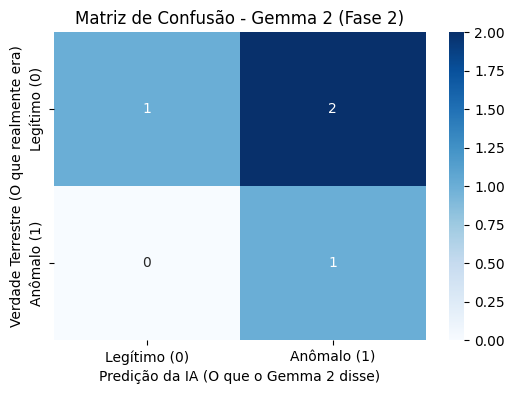

In [ ]:
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# =====================================================================
# 1. LEITURA SEGURA E AGRUPAMENTO DOS DADOS (TRIAGEM)
# =====================================================================
def ler_csv_seguro(caminho):
    linhas_processadas = []
    with open(caminho, 'r', encoding='utf-8') as f:
        cabecalho = f.readline().strip().split(',')
        for linha in f:
            partes = linha.strip().split(',', 4)
            if len(partes) == 5:
                linhas_processadas.append(partes)
    return pd.DataFrame(linhas_processadas, columns=cabecalho)

df = ler_csv_seguro('dataset_limpo_tcc.csv')

# Cria uma chave única de "Entidade" (Se tem Usuário, usa Usuário. Senão, usa IP)
df['Entidade'] = df['Usuario'].replace('', pd.NA).fillna(df['IP_Origem'])

# =====================================================================
# 2. DEFINIÇÃO DA VERDADE TERRESTRE (GROUND TRUTH)
# =====================================================================
ground_truth = {
    '95.161.22.128': 1, # Ataque Crítico
    '45.250.247.54': 1, # Ataque Automatizado
    'admin_tcc': 1,     # Ameaça Interna
    '195.241.151.7': 1, # Cenário A (Força Bruta inicial)
    '10.0.0.5': 0,      # Tráfego Legítimo / Ruído de Monitoramento
    'root': 0,          # Artefato / Lixo de parsing
    '': 0,              # Artefato / Lixo de parsing
    ' ': 0              # Artefato / Lixo de parsing
}

# =====================================================================
# 3. FUNÇÃO DE INFERÊNCIA REAL (GEMMA 2)
# =====================================================================
def classificar_com_gemma(timeline_text, entidade):
    prompt = f"""Você é um Analista de SOC Sênior.
Analise a linha do tempo de eventos abaixo e decida se o comportamento da entidade é 'ANÔMALO' (ataque/ofensor) ou 'LEGÍTIMO' (tráfego normal/ruído).

ALVO: {entidade}
LINHA DO TEMPO:
{timeline_text}

Responda ESTRITAMENTE neste formato:
**Veredito:** [Escreva apenas ANÔMALO ou LEGÍTIMO]
**Justificativa:** [Explique o motivo em um parágrafo curto]
"""

    mensagens = [{"role": "user", "content": prompt}]
    # Aplica o template do Gemma
    prompt_formatado = tokenizer.apply_chat_template(mensagens, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt_formatado, return_tensors="pt").to("cuda")

    # Geração com temperatura baixa (0.1) para forçar respostas mais determinísticas/lógicas
    outputs = model.generate(
        **inputs,
        max_new_tokens=200,
        temperature=0.1,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    resposta_ia = tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

    # Avalia a resposta gerada para extrair a métrica matemática
    # (Procura a palavra ANÔMALO no texto gerado)
    if "ANÔMALO" in resposta_ia.upper():
        return 1, resposta_ia
    else:
        return 0, resposta_ia

# =====================================================================
# 4. EXECUÇÃO DO TESTE (CLASSIFICAÇÃO LINHA POR LINHA DAS ENTIDADES)
# =====================================================================
print("===== INICIANDO AVALIAÇÃO QUANTITATIVA COM GEMMA 2 =====\n")

resultados_ia = {}

# Agrupa a linha do tempo por Entidade e envia para a IA
for entidade, dados_entidade in df.groupby('Entidade'):
    if entidade in ground_truth:
        # Pega as últimas 30 linhas da entidade para dar contexto sem estourar limite
        timeline = "\n".join(
            f"[{row['DataHora']}] - Ação: {row['Acao_Resumo']}"
            for _, row in dados_entidade.tail(30).iterrows()
        )

        print(f"Analisando alvo: {entidade}...")
        predicao, texto_resposta = classificar_com_gemma(timeline, entidade)
        resultados_ia[entidade] = predicao

        print(f"-> Verdade: {ground_truth[entidade]} | Gemma 2: {predicao}")
        print(f"-> Parecer da IA:\n{texto_resposta}\n{'-'*50}")

# =====================================================================
# 5. GERAÇÃO DAS MÉTRICAS E DA MATRIZ DE CONFUSÃO
# =====================================================================
y_true = [ground_truth[e] for e in resultados_ia.keys()]
y_pred = [resultados_ia[e] for e in resultados_ia.keys()]

# Calcula a Matriz
vn, fp, fn, vp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
precisao = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

print("\n--- RESULTADOS GERAIS DA AVALIAÇÃO QUANTITATIVA ---")
print(f"Verdadeiros Positivos (Ataques detectados): {vp}")
print(f"Falsos Positivos (Alarme falso): {fp}")
print(f"Verdadeiros Negativos (Ruído ignorado corretamente): {vn}")
print(f"Falsos Negativos (Ataques ignorados - Risco): {fn}")
print("-" * 51)
print(f"Precisão (Precision): {precisao:.2f}")
print(f"Sensibilidade (Recall): {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Plotagem
matriz = confusion_matrix(y_true, y_pred, labels=[0, 1])
plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítimo (0)', 'Anômalo (1)'],
            yticklabels=['Legítimo (0)', 'Anômalo (1)'])
plt.ylabel('Verdade Terrestre (O que realmente era)')
plt.xlabel('Predição da IA (O que o Gemma 2 disse)')
plt.title('Matriz de Confusão - Gemma 2 (Fase 2)')
plt.show()

--- RESULTADOS DA AVALIAÇÃO QUANTITATIVA ---
Verdadeiros Positivos (Ataques detectados): 1
Falsos Positivos (Alarme falso de ameaça): 2
Verdadeiros Negativos (Tráfego normal aceito): 1
Falsos Negativos (Ataques que passaram despercebidos): 0
--------------------------------------------
Precisão (Precision): 0.33
Sensibilidade (Recall): 1.00
F1-Score: 0.50


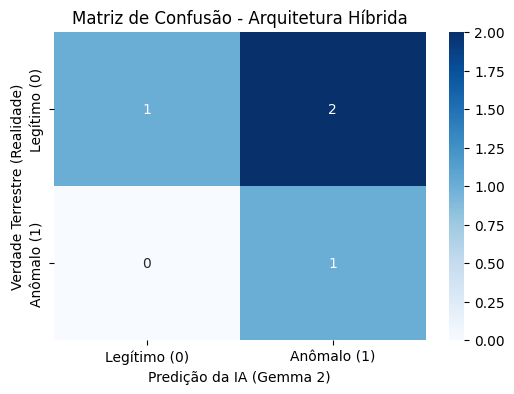

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Extrai os arrays para o cálculo
y_true = [ground_truth[e] for e in resultados_ia.keys()]
y_pred = [resultados_ia[e] for e in resultados_ia.keys()]

# Calcula a Matriz de Confusão
vn, fp, fn, vp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

# Calcula as métricas matemáticas
precisao = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("--- RESULTADOS DA AVALIAÇÃO QUANTITATIVA ---")
print(f"Verdadeiros Positivos (Ataques detectados): {vp}")
print(f"Falsos Positivos (Alarme falso de ameaça): {fp}")
print(f"Verdadeiros Negativos (Tráfego normal aceito): {vn}")
print(f"Falsos Negativos (Ataques que passaram despercebidos): {fn}")
print("-" * 44)
print(f"Precisão (Precision): {precisao:.2f}")
print(f"Sensibilidade (Recall): {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Plota a Matriz de Confusão
matriz = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legítimo (0)', 'Anômalo (1)'],
            yticklabels=['Legítimo (0)', 'Anômalo (1)'])
plt.ylabel('Verdade Terrestre (Realidade)')
plt.xlabel('Predição da IA (Gemma 2)')
plt.title('Matriz de Confusão - Arquitetura Híbrida')
plt.show()